In [3]:
import numpy as np
import pandas as pd
import warnings
import joblib
import subprocess
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

subprocess.run(["pip", "install", "shap", "-q"], check=True)
import shap

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

#  1. Yield forecast report — plot + numerical summary 

def forecast_report(unc: dict, t_observe_hours: float):
    """
    Takes the output of simulate_with_uncertainty and produces:
    1. The forecast plot with 90% CI bands
    2. Numerical penicillin value at the forecasted peak
    3. Numerical penicillin value at the end of batch
    """
    times    = unc["time"]
    pen_mean = unc["penicillin_mean"]
    pen_lo   = unc["penicillin_lower"]
    pen_hi   = unc["penicillin_upper"]
    bio_mean = unc["biomass_mean"]
    bio_lo   = unc["biomass_lower"]
    bio_hi   = unc["biomass_upper"]

    # Numerical summaries
    peak_idx  = np.argmax(pen_mean)
    peak_val  = pen_mean[peak_idx]
    peak_lo   = pen_lo[peak_idx]
    peak_hi   = pen_hi[peak_idx]
    peak_time = times[peak_idx]

    end_val  = pen_mean[-1]
    end_lo   = pen_lo[-1]
    end_hi   = pen_hi[-1]
    end_time = times[-1]

    print("=" * 50)
    print(f"  PENICILLIN YIELD FORECAST")
    print(f"  Observation cutoff : {t_observe_hours}h")
    print("=" * 50)
    print(f"  Forecasted peak    : {peak_val:.2f} g/L"
          f"  [90% CI: {peak_lo:.2f} – {peak_hi:.2f}]"
          f"  at t={peak_time:.1f}h")
    print(f"  Forecasted end     : {end_val:.2f} g/L"
          f"  [90% CI: {end_lo:.2f} – {end_hi:.2f}]"
          f"  at t={end_time:.1f}h")
    print("=" * 50)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Penicillin
    ax = axes[0]
    ax.plot(times, pen_mean,
            color="steelblue", linewidth=1.8, label="Forecast mean")
    ax.fill_between(times, pen_lo, pen_hi,
                    alpha=0.25, color="steelblue", label="90% CI")
    ax.plot(times, unc["actual_penicillin"],
            "--", color="coral", linewidth=1.5, label="Actual")

    ax.annotate(f"Peak: {peak_val:.1f} g/L\nat t={peak_time:.0f}h",
                xy=(peak_time, peak_val),
                xytext=(peak_time - 40, peak_val - 4),
                arrowprops=dict(arrowstyle="->", color="steelblue"),
                fontsize=9, color="steelblue")

    ax.annotate(f"End: {end_val:.1f} g/L\n[{end_lo:.1f}–{end_hi:.1f}]",
                xy=(end_time, end_val),
                xytext=(end_time - 60, end_val + 3),
                arrowprops=dict(arrowstyle="->", color="steelblue"),
                fontsize=9, color="steelblue")

    ax.axvline(t_observe_hours, color="gray", linestyle=":",
               linewidth=0.9, label=f"Cutoff t={t_observe_hours}h")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("Penicillin (g/L)")
    ax.set_title("Penicillin forecast with 90% CI")
    ax.legend()

    # Biomass
    ax = axes[1]
    ax.plot(times, bio_mean,
            color="steelblue", linewidth=1.8, label="Forecast mean")
    ax.fill_between(times, bio_lo, bio_hi,
                    alpha=0.25, color="steelblue", label="90% CI")
    ax.plot(times, unc["actual_biomass"],
            "--", color="coral", linewidth=1.5, label="Actual")
    ax.axvline(t_observe_hours, color="gray", linestyle=":",
               linewidth=0.9, label=f"Cutoff t={t_observe_hours}h")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("Biomass (g/L)")
    ax.set_title("Biomass forecast with 90% CI")
    ax.legend()

    plt.suptitle(f"Batch forecast from t={t_observe_hours}h",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig("04_forecast_report.png", dpi=150, bbox_inches="tight")
    plt.show()

    return {
        "peak_value": peak_val,
        "peak_ci":    (peak_lo, peak_hi),
        "peak_time":  peak_time,
        "end_value":  end_val,
        "end_ci":     (end_lo, end_hi),
        "end_time":   end_time,
    }

#  2. SHAP explanations on the delta models  

def explain_delta_models(model_p, model_x,
                         X_train: pd.DataFrame, features: list):
    """
    SHAP beeswarm + bar plots for both delta models.
    Subsamples 500 rows for speed — stable and representative.
    """
    for model, name in [(model_p, "Penicillin"), (model_x, "Biomass")]:
        print(f"\nComputing SHAP values for {name} delta model...")
        explainer   = shap.TreeExplainer(model)
        X_sample    = X_train.sample(min(500, len(X_train)), random_state=42)
        shap_values = explainer(X_sample)

        plt.figure()
        shap.plots.beeswarm(shap_values, max_display=16, show=False)
        plt.title(f"SHAP — {name} delta model (beeswarm)")
        plt.tight_layout()
        plt.show()

        plt.figure()
        shap.plots.bar(shap_values, max_display=16, show=False)
        plt.title(f"SHAP — {name} delta model (mean |SHAP|)")
        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------------ #
#  3. Full Day 4 pipeline                                             #
# ------------------------------------------------------------------ #

def run_day4(batch_df: pd.DataFrame, full_df: pd.DataFrame,
             t_observe_hours: float = 100.0,
             n_trajectories: int = 50):
    """
    Full Day 4 pipeline:
    1. Run Monte Carlo uncertainty simulation from t_observe_hours
    2. Plot forecast + print numerical summary at peak and end
    3. SHAP explanations on both delta models
    """
    model_p  = joblib.load("model_penicillin.pkl")
    model_x  = joblib.load("model_biomass.pkl")
    features = joblib.load("features.pkl")

    batch_df  = batch_df.sort_values("time").reset_index(drop=True)
    t_observe = (batch_df["time"] - t_observe_hours).abs().idxmin()

    print(f"Observation cutoff: row {t_observe} "
          f"(t={batch_df.loc[t_observe, 'time']:.1f}h)")

    
   # Monte Carlo uncertainty — tree sampling, no Gaussian noise
    def simulate_with_uncertainty(model_p, model_x, batch_df, features,
                                   t_observe, n_trajectories=30):
        batch_df  = batch_df.sort_values("time").reset_index(drop=True)
        n_rows    = len(batch_df)
        steps     = n_rows - t_observe - 1

        if steps <= 0:
            raise ValueError(f"t_observe={t_observe} leaves no rows to simulate. "
                             f"Batch has {n_rows} rows.")

        n_trees = len(model_p.estimators_)
        all_p   = np.zeros((n_trajectories, steps))
        all_x   = np.zeros((n_trajectories, steps))

        for traj in range(n_trajectories):
            pred_p = batch_df.loc[t_observe, "penicillin"]
            pred_x = batch_df.loc[t_observe, "biomass"]

            for step in range(steps):
                current_row = batch_df.iloc[[t_observe + step]].copy()

                current_row["penicillin_lag1"] = pred_p
                current_row["biomass_lag1"]    = pred_x

                if t_observe + step > 0:
                    current_row["our_lag1"] = batch_df.loc[t_observe + step - 1, "our"]

                X = current_row[features]

                tree_p = model_p.estimators_[np.random.randint(n_trees)]
                tree_x = model_x.estimators_[np.random.randint(n_trees)]

                delta_p = tree_p.predict(X)[0]
                delta_x = tree_x.predict(X)[0]

                pred_p = max(0.0, pred_p + delta_p)
                pred_x = max(0.0, pred_x + delta_x)

                all_p[traj, step] = pred_p
                all_x[traj, step] = pred_x

        actual_p = batch_df["penicillin"].values[t_observe + 1 : t_observe + 1 + steps]
        actual_x = batch_df["biomass"].values[t_observe + 1 : t_observe + 1 + steps]
        times    = batch_df["time"].values[t_observe + 1 : t_observe + 1 + steps]

        return {
            "time":              times,
            "penicillin_mean":   all_p.mean(axis=0),
            "penicillin_lower":  np.percentile(all_p, 5,  axis=0),
            "penicillin_upper":  np.percentile(all_p, 95, axis=0),
            "biomass_mean":      all_x.mean(axis=0),
            "biomass_lower":     np.percentile(all_x, 5,  axis=0),
            "biomass_upper":     np.percentile(all_x, 95, axis=0),
            "actual_penicillin": actual_p,
            "actual_biomass":    actual_x,
        }

    unc = simulate_with_uncertainty(
        model_p, model_x, batch_df, features,
        t_observe=t_observe,
        n_trajectories=n_trajectories
    )

    summary = forecast_report(unc, t_observe_hours)

    # Rebuild X_train for SHAP
    full_df = full_df.copy()
    
    full_df["penicillin"] = full_df.groupby("batch_id")["penicillin"].ffill()
    full_df["biomass"]    = full_df.groupby("batch_id")["biomass"].ffill()
    full_df["penicillin_lag1"] = full_df["penicillin_lag1"].fillna(full_df["penicillin"])
    full_df["penicillin_next"] = full_df.groupby("batch_id")["penicillin"].shift(-1)
    full_df["biomass_next"]    = full_df.groupby("batch_id")["biomass"].shift(-1)

    full_df["penicillin_delta"] = full_df["penicillin_next"] - full_df["penicillin"]
    full_df["biomass_delta"]    = full_df["biomass_next"]    - full_df["biomass"]

    full_df = full_df[
        full_df["penicillin_next"].notna() &
        full_df["biomass_next"].notna() &
        full_df["penicillin_delta"].notna() &
        full_df["biomass_delta"].notna()
    ].copy()

    batches = full_df["batch_id"].unique()
    split = int(0.8 * len(batches))

    train_df = full_df[full_df["batch_id"].isin(batches[:split])]
    test_df  = full_df[full_df["batch_id"].isin(batches[split:])]

    X_train = train_df[features]
    X_test  = test_df[features]

    y_train_p = train_df["penicillin_delta"]
    y_test_p  = test_df["penicillin_delta"]

    y_train_x = train_df["biomass_delta"]
    y_test_x  = test_df["biomass_delta"]
    

    explain_delta_models(model_p, model_x, X_train, features)

    return summary



Observation cutoff: row 199 (t=40.0h)
  PENICILLIN YIELD FORECAST
  Observation cutoff : 40.0h
  Forecasted peak    : 26.96 g/L  [90% CI: 26.75 – 27.15]  at t=160.4h
  Forecasted end     : 18.87 g/L  [90% CI: 18.57 – 19.14]  at t=230.0h


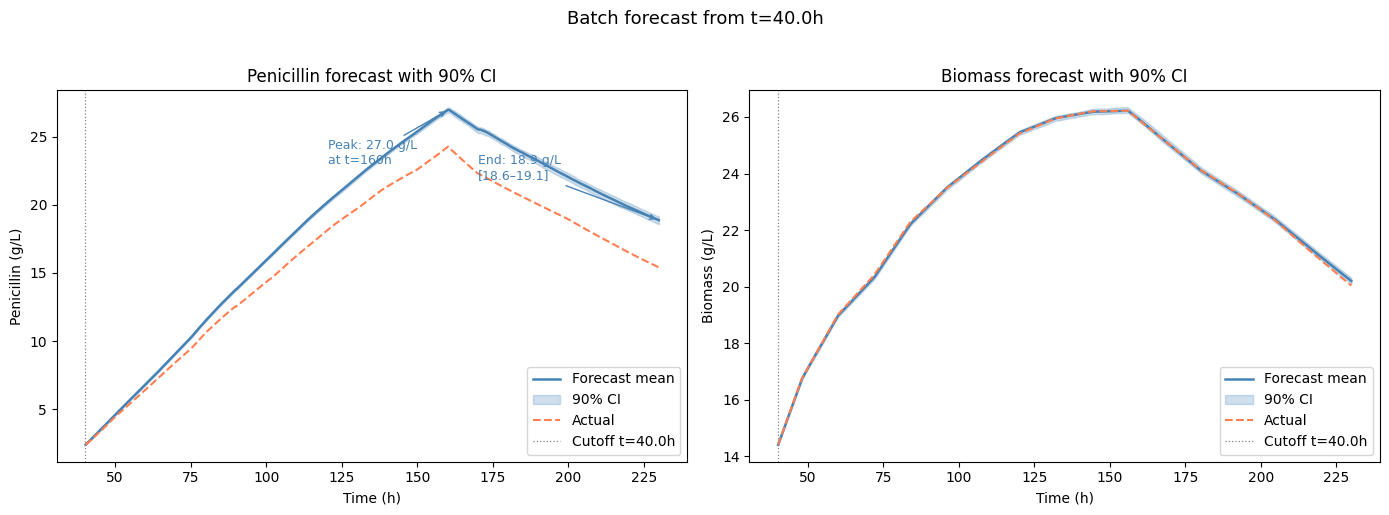


Computing SHAP values for Penicillin delta model...


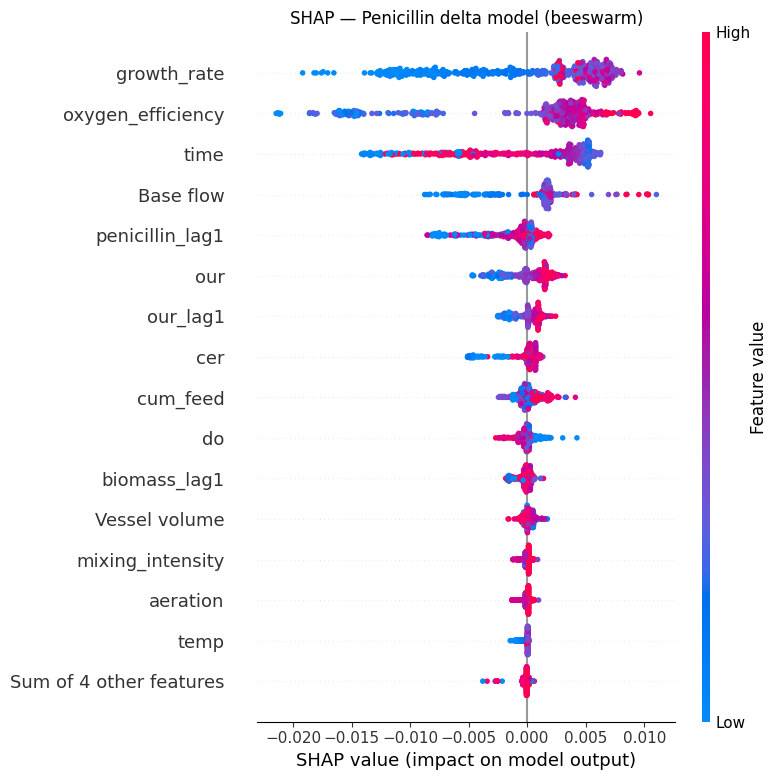

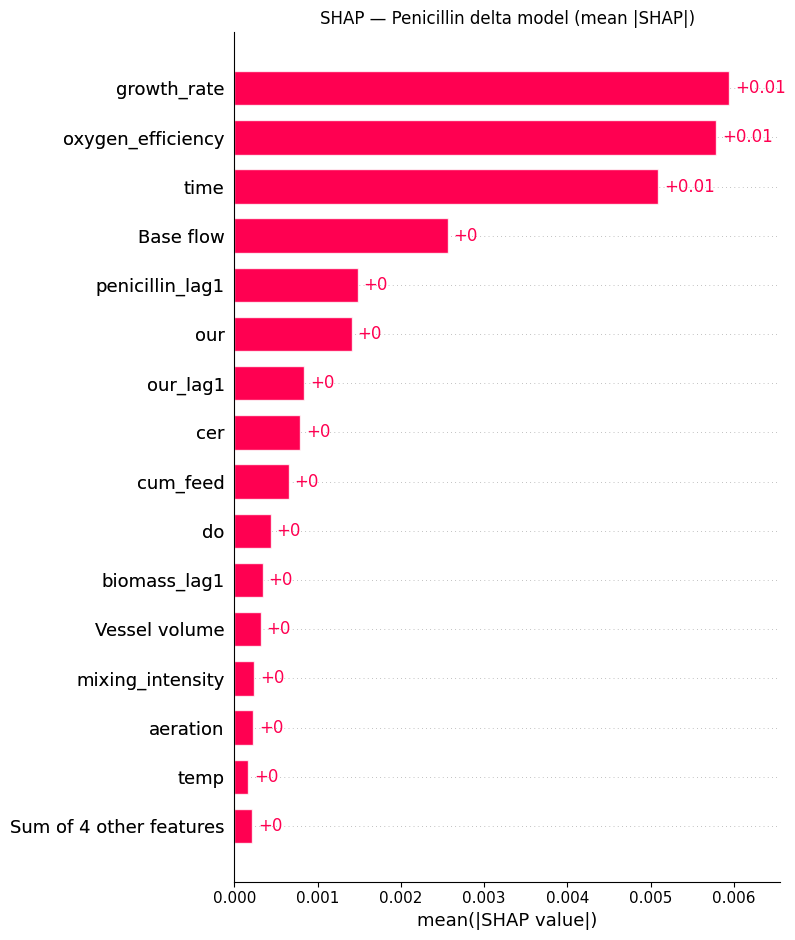


Computing SHAP values for Biomass delta model...


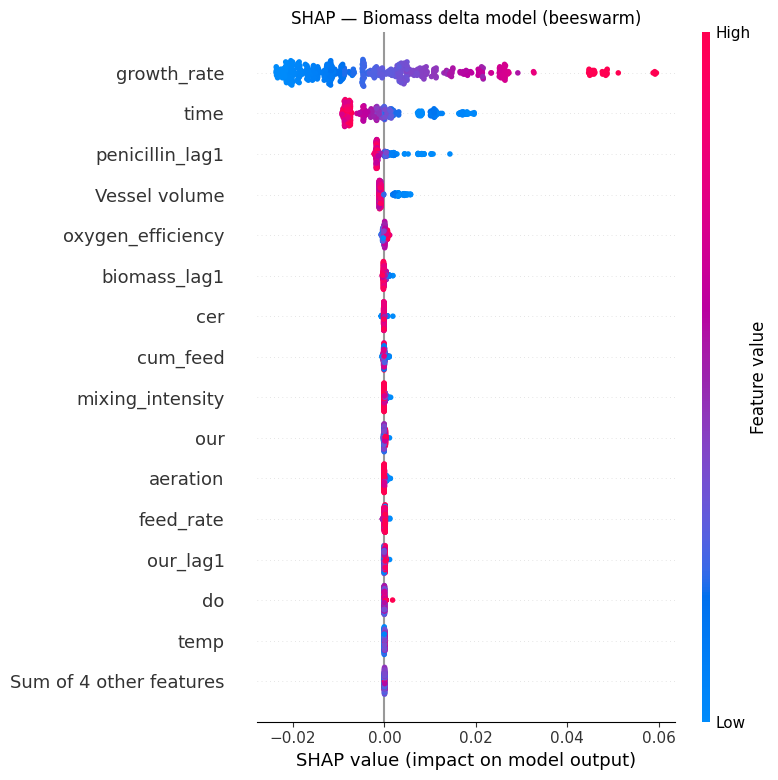

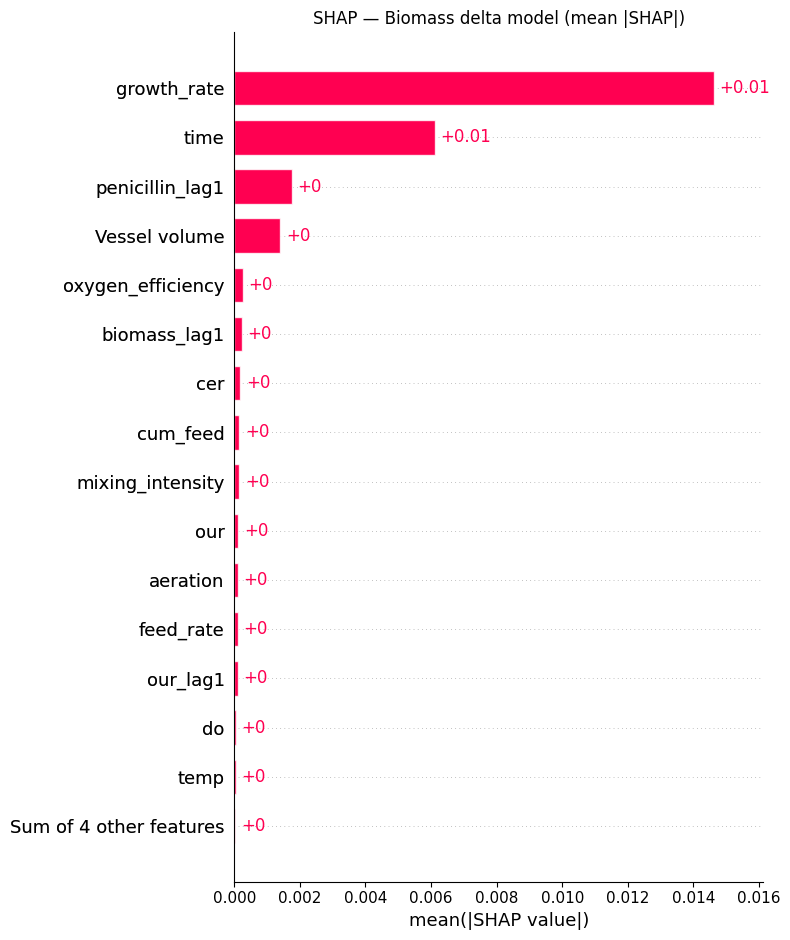

In [4]:
#Example: batch 10
if __name__ == "__main__":
    df       = pd.read_csv("../Data/processed_data.csv")
    batch_id = df["batch_id"].unique()[-1]
    batch_df = df[df["batch_id"] == batch_id].reset_index(drop=True)

    summary = run_day4(
        batch_df        = batch_df,
        full_df         = df,
        t_observe_hours = 40.0,
        n_trajectories  = 30
    )